In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import kind
import utils_data
import utils_plot

In [3]:
# --!--------------------------------------------------------------------------
# --! load trained models

model = torch.load('../../models/baselines/odmd_kind_sim.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=50, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=250, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=6, out_features=3, bias=False)
    (mod_mean): Linear(in_features=3, out_features=3, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=15, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=72, bias=True)

Parameter containing:
tensor([[-0.0211, -0.8434,  0.3434],
        [ 0.8652, -0.0850, -0.4299],
        [-0.3159,  0.1811, -0.1782]])


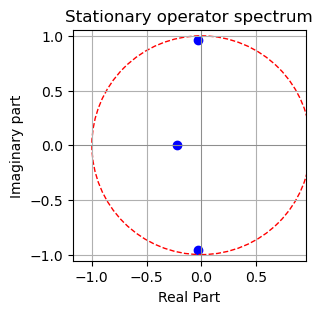

In [4]:
# --!--------------------------------------------------------------------------!
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

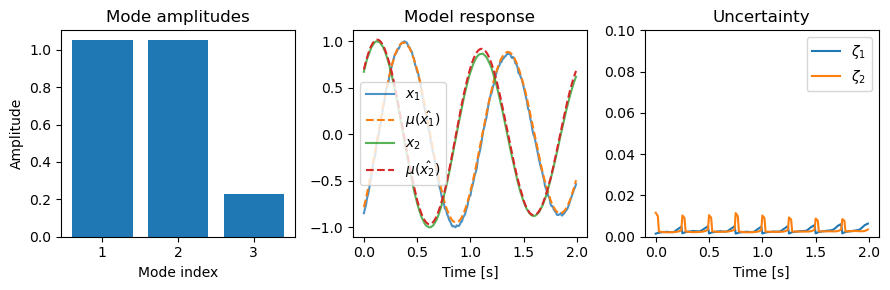

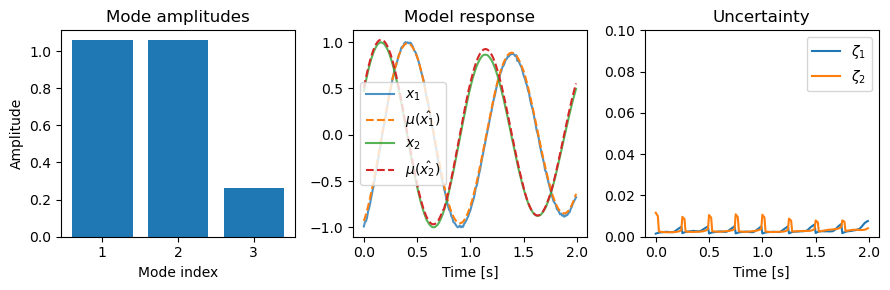

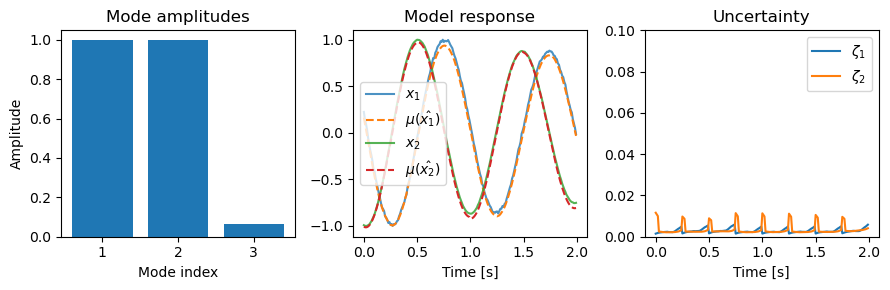

In [5]:
# --!--------------------------------------------------------------------------!
# --! analyze the contribution of stationary operator eigenvalues

datadir            = '../../data/baselines/train_sim_stat'
timeseries_nsample = 200

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

In [6]:
# --! make forecasts in a manner of a sliding window --!

# --! read test data
datadir            = '../../data/baselines/test_sim'
timeseries_nsample = 200
data               = utils_data.read_datafile(f'{datadir}/eval', timeseries_nsample)
data               = data.reshape(-1, data.shape[-1])

# --! get window constants from the model
lookback_nsample   = model.lookback_nsample
forecast_nsample   = model.forecast_nsample
forecast_begin     = lookback_nsample
forecast_end       = data.shape[0] - forecast_nsample
lookback           = data[:lookback_nsample]

print(f'inf >> forecasting from {forecast_begin} till {forecast_end}')

mse = []

# --! the lookback window is already full, so we can start the sliding forecasts
#
# --! forecasts are compared to the actual data - the truth - and a mean
# --! square error is calculated each time
with torch.no_grad():
    for j in range(forecast_begin, forecast_end):

        # --! concatenate the current lookback and the true forecast to have a properly normalized forecast region
        # --! for comparison afterward
        traj = torch.unsqueeze(torch.cat([lookback, data[j:j+forecast_nsample, :]], dim=0), dim=0)

        # --! normalize concatenated trajectory
        mean   = torch.mean(traj, dim=1, keepdim=True)
        traj   = traj - mean
        scaler = utils_data.minmax_scaler(feature_range=(-1, 1))
        traj   = scaler.fit_transform(traj)

        # --! extract normalized lookback and call forward method directly to
        # --! bypass model internal normalization
        model_i  = traj[:, :lookback_nsample, :]
        model_o  = torch.squeeze(model._get_mode()._forward(model_i)[0], dim=0)

        # --! extract predicted forecast region
        forecast = model_o[lookback_nsample:]

        # --! extract true forecast region
        truth = traj[0, lookback_nsample:]

        # --! calculate mean square error
        loss_fn = torch.nn.MSELoss(reduction='mean')
        mse.append(loss_fn(forecast, truth))

        # --! update lookback with a new measurement
        meas     = data[[j]]
        lookback = torch.cat([lookback[1:], meas], dim=0)


inf >> forecasting from 125 till 525


inf >> average mse is 0.002571078250184655
inf >> worst offset is 399
inf >> best offset is 46


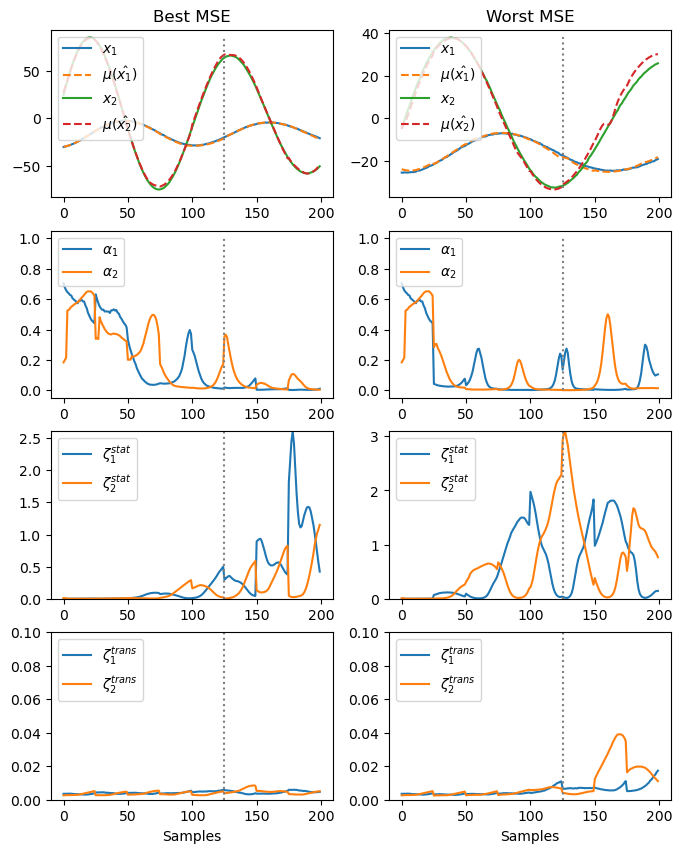

In [7]:
jworst = np.argmax(mse)
jbest  = np.argmin(mse)
avg    = np.mean(mse)
print(f'inf >> average mse is {avg}')
print(f'inf >> worst offset is {jworst}')
print(f'inf >> best offset is {jbest}')

with torch.no_grad():
    lookback           = data[jbest:jbest + lookback_nsample, :]
    model_i            = torch.unsqueeze(lookback, dim=0)
    model_o            = model(model_i)
    mean_best          = model_o[0]
    stat_logvar_best   = model_o[2]
    trans_logvar_best  = model_o[4]
    alpha_best         = model_o[9]
    mean_best          = torch.squeeze(mean_best, dim=0)
    stat_logvar_best   = torch.squeeze(stat_logvar_best, dim=0)
    trans_logvar_best  = torch.squeeze(trans_logvar_best, dim=0)
    alpha_best         = torch.squeeze(alpha_best, dim=0)
    stat_var_best      = torch.exp(stat_logvar_best) + 1e-6
    trans_var_best     = torch.exp(trans_logvar_best) + 1e-6
    truth_best         = data[jbest:jbest + timeseries_nsample, :]

    lookback           = data[jworst:jworst + lookback_nsample, :]
    model_i            = torch.unsqueeze(lookback, dim=0)
    model_o            = model(model_i)
    mean_worst         = model_o[0]
    stat_logvar_worst  = model_o[2]
    trans_logvar_worst = model_o[4]
    alpha_worst        = model_o[9]
    mean_worst         = torch.squeeze(mean_worst, dim=0)
    alpha_worst        = torch.squeeze(alpha_worst, dim=0)
    stat_logvar_worst  = torch.squeeze(stat_logvar_worst, dim=0)
    trans_logvar_worst = torch.squeeze(trans_logvar_worst, dim=0)
    stat_var_worst     = torch.exp(stat_logvar_worst) + 1e-6
    trans_var_worst    = torch.exp(trans_logvar_worst) + 1e-6
    truth_worst        = data[jworst:jworst + timeseries_nsample, :]

    plt.figure(figsize=(8, 10))

    maxo = torch.max(truth_best)
    mino = torch.min(truth_best)
    plt.subplot(4, 2, 1)
    plt.title('Best MSE')
    for k in range(model.timeseries_ndim):
        plt.plot(truth_best[:, k], label='$x_{' + f'{k+1}' + '}$')
        plt.plot(mean_best[:, k], linestyle='dashed', label='$\\mu(\\hat{x_{' + f'{k+1}' + '}})$')
    plt.plot([forecast_begin, forecast_begin], [mino, maxo], linestyle='dotted', color='gray')
    plt.legend(loc="upper left")

    maxo = torch.max(truth_worst)
    mino = torch.min(truth_worst)
    plt.subplot(4, 2, 2)
    plt.title('Worst MSE')
    for k in range(model.timeseries_ndim):
        plt.plot(truth_worst[:, k], label='$x_{' + f'{k+1}' + '}$')
        plt.plot(mean_worst[:, k], linestyle='dashed', label='$\\mu(\\hat{x_{' + f'{k+1}' + '}})$')
    plt.plot([forecast_begin, forecast_begin], [mino, maxo], linestyle='dotted', color='gray')
    plt.legend(loc="upper left")

    plt.subplot(4, 2, 3)
    for k in range(model.timeseries_ndim):
        plt.plot(alpha_best[:, k], linestyle='solid', label='$\\alpha_{' + f'{k+1}' + '}$')
    plt.plot([forecast_begin, forecast_begin], [0, 1], linestyle='dotted', color='gray')
    plt.legend(loc="upper left")

    plt.subplot(4, 2, 4)
    for k in range(model.timeseries_ndim):
        plt.plot(alpha_worst[:, k], linestyle='solid', label='$\\alpha_{' + f'{k+1}' + '}$')
    plt.plot([forecast_begin, forecast_begin], [0, 1], linestyle='dotted', color='gray')
    plt.legend(loc="upper left")

    plt.subplot(4, 2, 5)
    maxvar = torch.max(stat_var_best)
    maxvar = 0.1 if maxvar < 0.1 else maxvar
    for k in range(model.timeseries_ndim):
        plt.plot(stat_var_best[:, k], linestyle='solid', label='$\\zeta^{stat}_{' + f'{k+1}' + '}$')
    plt.plot([forecast_begin, forecast_begin], [0, maxvar], linestyle='dotted', color='gray')
    plt.ylim((0., maxvar))
    plt.legend(loc="upper left")

    plt.subplot(4, 2, 6)
    maxvar = torch.max(stat_var_worst)
    maxvar = 0.1 if maxvar < 0.1 else maxvar
    for k in range(model.timeseries_ndim):
        plt.plot(stat_var_worst[:, k], linestyle='solid', label='$\\zeta^{stat}_{' + f'{k+1}' + '}$')
    plt.plot([forecast_begin, forecast_begin], [0, maxvar], linestyle='dotted', color='gray')
    plt.ylim((0., maxvar))
    plt.legend(loc="upper left")

    plt.subplot(4, 2, 7)
    maxvar = torch.max(trans_var_best)
    maxvar = 0.1 if maxvar < 0.1 else maxvar
    for k in range(model.timeseries_ndim):
        plt.plot(trans_var_best[:, k], linestyle='solid', label='$\\zeta^{trans}_{' + f'{k+1}' + '}$')
    plt.plot([forecast_begin, forecast_begin], [0, maxvar], linestyle='dotted', color='gray')
    plt.ylim((0., maxvar))
    plt.legend(loc="upper left")
    plt.xlabel('Samples')

    plt.subplot(4, 2, 8)
    maxvar = torch.max(trans_var_worst)
    maxvar = 0.1 if maxvar < 0.1 else maxvar
    for k in range(model.timeseries_ndim):
        plt.plot(trans_var_worst[:, k], linestyle='solid', label='$\\zeta^{trans}_{' + f'{k+1}' + '}$')
    plt.plot([forecast_begin, forecast_begin], [0, maxvar], linestyle='dotted', color='gray')
    plt.ylim((0., maxvar))
    plt.legend(loc="upper left")
    plt.xlabel('Samples')

    plt.show()
